In [ ]:
#!/usr/bin/env python3

"""
This code downloads event waveforms from the SCEDC Open Data Set for events that occurred 
in a particular year and month and exceed a certain magnitude.
"""

import pandas as pd
import re
import boto3
import os
import matplotlib.pyplot as plt
import numpy as np

from botocore import UNSIGNED
from botocore.config import Config


# S3 connection
s3cli = boto3.client('s3',config=Config(signature_version=UNSIGNED))
s3res = boto3.resource('s3',config=Config(signature_version=UNSIGNED))

# Bucket parameters.
BUCKET_NAME = 'scedc-pds'
PARENT_DIR = 'event_waveforms'

# Function definitions

def get_prefix(event_time):
    """ Creates the Open Data Set prefix for an event given the origin time
    as a Pandas timestamp.
    """
    return '{}/{}_{:03d}/'.format(event_time.year, event_time.year, event_time.dayofyear)


def get_events(year, month, mag):
    """ Get all the events in the SCEDC catalog that occurred in a given year and month and 
    exceed a given magnitude. Return the events in a dataframe.
    """
    # Get the catalog for the year.
    catalog_file = '{}_catalog_index.csv'.format(year)
    print(catalog_file)
    s3cli.download_file('scedc-pds', 'earthquake_catalogs/index/csv/year={}/{}'.format(year, catalog_file), catalog_file)
    #catalog = pd.read_csv(catalog_file, index_col=False)
    catalog = pd.read_csv(catalog_file)

    # Convert eventdate column from string to Timestamp.
    if 'ORIGIN_DATETIME' in catalog.columns:
        catalog['eventdate'] = pd.to_datetime(catalog['ORIGIN_DATETIME'])
    elif 'YYYY/MM/DD' in catalog.columns:
        catalog['eventdate'] = pd.to_datetime(catalog['YYYY/MM/DD'])
    
    # Get the events that meet the criteria.
    df = catalog[ (catalog['eventdate'].dt.year==year) \
                    & (catalog['eventdate'].dt.month==month) \
                    & (catalog['MAG']>=mag) ]
  
    return df


def download_objects(download_files):
    """ Downloads a list of files from the SCEDC Open Data Set,
    given their object keys.
    """
    for f in download_files:
        # The output file will just be the name of the key without the prefix.
        output_file = f.split('/')[-1]
        print('Downloading {} to {}.'.format(f, output_file))
        s3cli.download_file('scedc-pds', f, output_file )
        
        
def list_objects(evid, prefix):
    """ Returns a list of object names that match an event,
    given the event ID and the Open Data Set prefix of the event.    
    """
    
    #print('list-objects {} {}', evid, prefix)
    # Create a regular expression to match the event ID followed by any suffixes.
    regex = re.compile('.*\/{}[a-b]?\.ms.*$'.format(evid))

    obj_names = []
    full_prefix = PARENT_DIR + '/' + prefix
    #print(full_prefix)
    for obj in s3res.Bucket('scedc-pds').objects.filter(Prefix=full_prefix):
        if regex.match(obj.key):
            print('Match {}'.format(obj.key))
            obj_names.append(obj.key)
            
    return obj_names

def download_events(year, month, mag):
    """ Download waveforms for events in the SCEDC Open Data Set that occurred in
    the given year and month and exceed the given magnitude.
    """

    # Get events from the catalog.
    df = get_events(year, month, mag)

    # This step is no longer needed because the prefix is included
    # in the catalog.
    # Determine the S3 prefix for each event.
    if 'PREFIX' not in df.columns:
        df['PREFIX'] = df['eventdate'].apply(get_prefix)       
    
    download_files = []
    for _, row in df[['EVID', 'PREFIX']].iterrows():
        # Append onto download_files the names of objects that match the event ID.
        download_files.extend(list_objects(row['EVID'], row['PREFIX']))
    download_objects(download_files)


def main():
    import argparse
    parser = argparse.ArgumentParser(description='Download event waveforms from the SCEDC Open Data Set by year, month, and magnitude threshold.')
    parser.add_argument('--year', dest='year', type=int, required=True)
    parser.add_argument('--month', dest='month', type=int, required=True)
    parser.add_argument('--mag', dest='mag', type=float, default=-2)
    args = parser.parse_args()
    download_events(args.year, args.month, args.mag)

def get_filenames(df):
    strs = df[['PREFIX','MS_FILENAME']][df['MS_FILENAME'].values.astype(str)!='nan'].values
    strs = list('event_waveforms/' + strs[:,0] + strs[:,1])

    return strs


# if __name__ == '__main__':
#     main()

year = 2020

project_dir = 'test_download/'
cat_dir = project_dir + 'catalog/'
events_dir = project_dir + 'events/'


os.makedirs(project_dir, exist_ok=True)
os.makedirs(cat_dir, exist_ok=True)
os.makedirs(events_dir, exist_ok=True)


catalog_file = '{}_catalog_index.csv'.format(year)
print(catalog_file)
s3cli.download_file('scedc-pds', 'earthquake_catalogs/index/csv/year={}/{}'.format(year, catalog_file), cat_dir + catalog_file)


<>:79: SyntaxWarning: invalid escape sequence '\/'
<>:79: SyntaxWarning: invalid escape sequence '\/'
/var/folders/n9/y3b20y1x2dx7n3qq1qn2cn2m000jzz/T/ipykernel_9216/3906226647.py:79: SyntaxWarning: invalid escape sequence '\/'
  regex = re.compile('.*\/{}[a-b]?\.ms.*$'.format(evid))


2020_catalog_index.csv


In [ ]:
catalog = pd.read_csv(cat_dir + catalog_file)
catalog = catalog[catalog['MAG']>=2.5]

if 'PREFIX' not in catalog.columns:
    catalog['PREFIX'] = catalog['eventdate'].apply(get_prefix)  



In [ ]:
os.makedirs('tmp', exist_ok=True)
filenames = get_filenames(catalog)

for f in filenames[:1]:
    # The output file will just be the name of the key without the prefix.
    event_dir = events_dir + f.split('/')[-1].split('.')[0] + '/'
    os.makedirs(event_dir, exist_ok=True)
    output_file = f.split('/')[-1]
    # output_file = f.split('/')[-1].split('.')[0]
    print('Downloading {} to {}.'.format(f, "tmp/" + output_file))
    s3cli.download_file('scedc-pds', f, "tmp/" + output_file )
    st = obspy.read("tmp/" + output_file)
    # lst = s3cli.list_objects_v2(Bucket='scedc-pds', Prefix=f)


In [105]:
st = st.select(sampling_rate=100, channel="H*", component="Z")

In [108]:
st[0].stats

         network: AZ
         station: BZN
        location: 
         channel: HHZ
       starttime: 2020-01-01T10:38:17.418300Z
         endtime: 2020-01-01T10:40:55.178300Z
   sampling_rate: 100.0
           delta: 0.01
            npts: 15777
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'D', 'number_of_records': 39, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 512, 'filesize': 52424192})

/Users/ivandevert/miniconda3/envs/hilorat/lib/python3.12/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/Users/ivandevert/miniconda3/envs/hilorat/lib/python3.12/site-packages/obspy/imaging/waveform.py:815: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


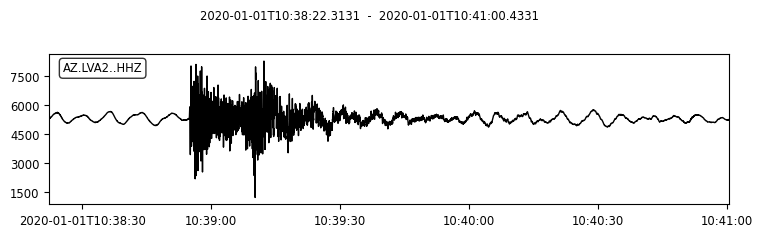

/Users/ivandevert/miniconda3/envs/hilorat/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  fig.canvas.print_figure(bytes_io, **kw)


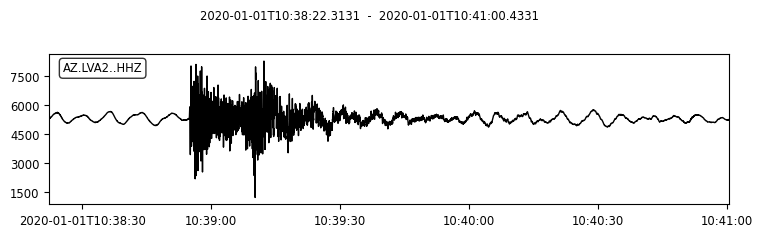

In [110]:
st[10].plot()

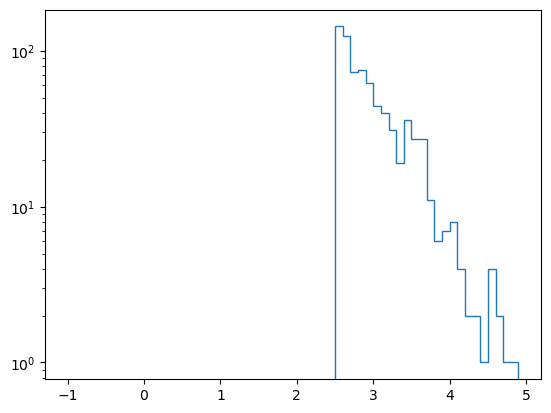

In [111]:

plt.figure()
plt.hist(catalog['MAG'], bins=np.arange(-1, 5, 0.1), histtype='step')
plt.yscale('log')
plt.show()